In [23]:
!pip install torch

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
class Generator(nn.Module):
    def __init__(self,z_dim,channels_g,feature_g):
        super(Generator,self).__init__()

        self.net_G=nn.Sequential(

            nn.ConvTranspose2d(64, 512, 4, 1, 0, bias=False),  # -> (batch, 512, 4, 4)
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False), # -> (batch, 256, 8, 8)
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), # -> (batch, 128, 16, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),  # -> (batch, 64, 32, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 3, 1, 1, bias=False),    # -> (batch, 3, 32, 32)
            nn.Tanh() 
        )
    def forward (self,x):
        return self.net_G(x)
    
class critic(nn.Module):
    def __init__(self,channels_C,features_C):
        super(critic,self).__init__()

        self.net_C = nn.Sequential(

            nn.Conv2d(3, 64, 4, 2, 1),   # -> (batch, 64, 16, 16)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1), # -> (batch, 128, 8, 8)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),# -> (batch, 256, 4, 4)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1),# -> (batch, 512, 2, 2)
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 2, 1, 0),  # -> (batch, 1, 1, 1)
        )

    def forward (self,x):
        return self.net_C(x).view(-1)


In [27]:
def gradient_penalty (critic,real,fake,device):
    batch_size,C,H,W = real.shape

    epilson = torch.rand(batch_size,1,1,1).repeat(1,C,H,W).to(device)

    interpolated_images = real * epilson + fake * (1-epilson)
    interpolated_images.requires_grad_(True)

    mixed_score = critic(interpolated_images)
    gradient=torch.autograd.grad(
        inputs=interpolated_images,
        outputs=mixed_score,
        grad_outputs=torch.ones_like(mixed_score),
        create_graph=True,
        retain_graph=True
    )[0]

    gradient=gradient.view(batch_size,-1)
    gradient_norm=gradient.norm(2,dim=1)

    gp = torch.mean((gradient_norm-1)**2)
    return gp

In [28]:
z_dim = 64
channels_img = 3
features_g = 64
features_d = 64

net_G = Generator(z_dim, channels_img, features_g).to(device)
net_D = critic(channels_img, features_d).to(device)
opt_G=torch.optim.Adam(net_G.parameters(),lr=1e-4,betas=(0.0,0.9))
opt_D=torch.optim.Adam(net_D.parameters(),lr=1e-4,betas=(0.0,0.9))

In [29]:
import torchvision
from torchvision import transforms,datasets
from torch.utils.data import DataLoader
from PIL import Image

transform = transforms.Compose(
    [transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)]
)

def pil_loader(path):
    return Image.open(path).convert("RGB")

data=torchvision.datasets.CIFAR10(
    download=True,
    train=True,
    transform=transform,
    root="./data"
)


Files already downloaded and verified


In [30]:
loader=DataLoader(data,batch_size=64,shuffle=True)

In [31]:
lambda_gp = 10
critic_iterations = 5
epochs = 10

for epoch in range(epochs):
    for real, _ in loader:

        real = real.to(device)
        batch_size = real.size(0)

        # ---------------------
        # Train Critic
        # ---------------------
        for _ in range(critic_iterations):

            noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
            fake = net_G(noise)

            D_real = net_D(real)
            D_fake = net_D(fake.detach())

            gp = gradient_penalty(net_D, real, fake, device)

            loss_D = -(torch.mean(D_real) - torch.mean(D_fake)) + lambda_gp * gp

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = net_G(noise)
        D_fake = net_D(fake)

        loss_G = -torch.mean(D_fake)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch} | Critic Loss: {loss_D:.4f} | Generator Loss: {loss_G:.4f}")

KeyboardInterrupt: 

In [32]:
import matplotlib.pyplot as plt 

Epoch [0/10] Batch [0/782]                         Critic Loss: -50.5811 Generator Loss: 25.3328


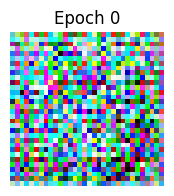

Epoch [0/10] Batch [0/782]                         Critic Loss: -50.5811 Generator Loss: 24.8493


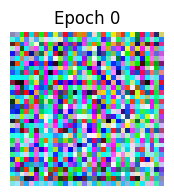

Epoch [0/10] Batch [0/782]                         Critic Loss: -50.5811 Generator Loss: 22.0155


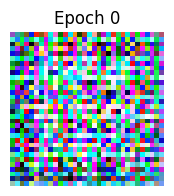

End of Epoch 0 | Critic Loss: -50.5811 | Generator Loss: 22.0155
End of Epoch 0 | Critic Loss: -49.8140 | Generator Loss: 18.5796
End of Epoch 0 | Critic Loss: -51.3288 | Generator Loss: 23.7538
End of Epoch 0 | Critic Loss: -53.1539 | Generator Loss: 25.6593
End of Epoch 0 | Critic Loss: -54.5060 | Generator Loss: 27.3245
End of Epoch 0 | Critic Loss: -56.0028 | Generator Loss: 26.9421
End of Epoch 0 | Critic Loss: -57.4507 | Generator Loss: 22.5397
End of Epoch 0 | Critic Loss: -58.4011 | Generator Loss: 25.4915
End of Epoch 0 | Critic Loss: -59.3398 | Generator Loss: 25.4692
End of Epoch 0 | Critic Loss: -60.8601 | Generator Loss: 28.9408
End of Epoch 0 | Critic Loss: -62.4447 | Generator Loss: 30.2566
End of Epoch 0 | Critic Loss: -63.3735 | Generator Loss: 28.5837
End of Epoch 0 | Critic Loss: -64.7693 | Generator Loss: 30.1446
End of Epoch 0 | Critic Loss: -65.6374 | Generator Loss: 30.3787
End of Epoch 0 | Critic Loss: -67.1290 | Generator Loss: 32.0292
End of Epoch 0 | Critic L

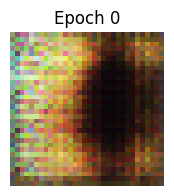

Epoch [0/10] Batch [200/782]                         Critic Loss: -3.8976 Generator Loss: 58.9193


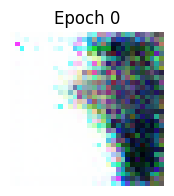

Epoch [0/10] Batch [200/782]                         Critic Loss: -3.8976 Generator Loss: 58.1589


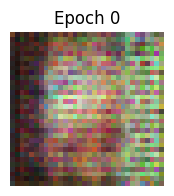

End of Epoch 0 | Critic Loss: -3.8976 | Generator Loss: 58.1589
End of Epoch 0 | Critic Loss: -3.3934 | Generator Loss: 58.2690
End of Epoch 0 | Critic Loss: -4.3084 | Generator Loss: 56.4099
End of Epoch 0 | Critic Loss: -4.1303 | Generator Loss: 57.2262
End of Epoch 0 | Critic Loss: -4.7031 | Generator Loss: 56.5840
End of Epoch 0 | Critic Loss: -3.9314 | Generator Loss: 55.8661
End of Epoch 0 | Critic Loss: -4.1731 | Generator Loss: 55.4354
End of Epoch 0 | Critic Loss: -3.9830 | Generator Loss: 54.0898
End of Epoch 0 | Critic Loss: -8.0976 | Generator Loss: 50.2989
End of Epoch 0 | Critic Loss: -5.8928 | Generator Loss: 53.3773
End of Epoch 0 | Critic Loss: -3.7053 | Generator Loss: 53.5581
End of Epoch 0 | Critic Loss: -4.9674 | Generator Loss: 51.9951
End of Epoch 0 | Critic Loss: -7.0834 | Generator Loss: 50.7958
End of Epoch 0 | Critic Loss: -4.3247 | Generator Loss: 50.8163
End of Epoch 0 | Critic Loss: -7.1120 | Generator Loss: 47.9393
End of Epoch 0 | Critic Loss: -5.0313 | 

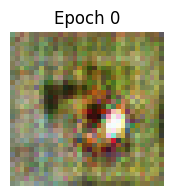

Epoch [0/10] Batch [400/782]                         Critic Loss: -3.6115 Generator Loss: 28.8032


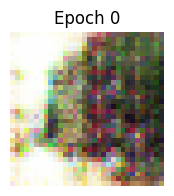

Epoch [0/10] Batch [400/782]                         Critic Loss: -3.6115 Generator Loss: 27.8275


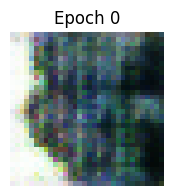

End of Epoch 0 | Critic Loss: -3.6115 | Generator Loss: 27.8275
End of Epoch 0 | Critic Loss: -4.1675 | Generator Loss: 31.5550
End of Epoch 0 | Critic Loss: -4.1190 | Generator Loss: 29.7642
End of Epoch 0 | Critic Loss: -3.6902 | Generator Loss: 28.7695
End of Epoch 0 | Critic Loss: -5.6004 | Generator Loss: 28.4474
End of Epoch 0 | Critic Loss: -3.7279 | Generator Loss: 31.6172
End of Epoch 0 | Critic Loss: -4.0876 | Generator Loss: 30.1851
End of Epoch 0 | Critic Loss: -3.7392 | Generator Loss: 32.1620
End of Epoch 0 | Critic Loss: -4.9235 | Generator Loss: 29.0390
End of Epoch 0 | Critic Loss: -4.7167 | Generator Loss: 29.9470
End of Epoch 0 | Critic Loss: -4.4380 | Generator Loss: 30.3049
End of Epoch 0 | Critic Loss: -4.0642 | Generator Loss: 32.8461
End of Epoch 0 | Critic Loss: -4.7061 | Generator Loss: 31.3241
End of Epoch 0 | Critic Loss: -4.9290 | Generator Loss: 28.2193
End of Epoch 0 | Critic Loss: -5.6962 | Generator Loss: 30.7703
End of Epoch 0 | Critic Loss: -2.7987 | 

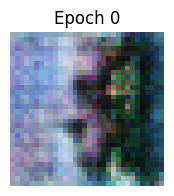

Epoch [0/10] Batch [600/782]                         Critic Loss: -3.5885 Generator Loss: 21.6002


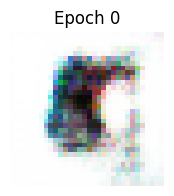

Epoch [0/10] Batch [600/782]                         Critic Loss: -3.5885 Generator Loss: 21.2204


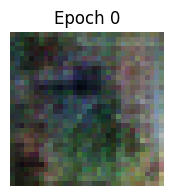

End of Epoch 0 | Critic Loss: -3.5885 | Generator Loss: 21.2204
End of Epoch 0 | Critic Loss: -4.0930 | Generator Loss: 21.5498
End of Epoch 0 | Critic Loss: -4.5537 | Generator Loss: 22.7709
End of Epoch 0 | Critic Loss: -4.5017 | Generator Loss: 20.9774
End of Epoch 0 | Critic Loss: -4.7065 | Generator Loss: 18.6465
End of Epoch 0 | Critic Loss: -2.8959 | Generator Loss: 19.8015
End of Epoch 0 | Critic Loss: -4.3559 | Generator Loss: 19.9327
End of Epoch 0 | Critic Loss: -4.1590 | Generator Loss: 21.6921
End of Epoch 0 | Critic Loss: -3.5474 | Generator Loss: 21.3964
End of Epoch 0 | Critic Loss: -4.3434 | Generator Loss: 20.4863
End of Epoch 0 | Critic Loss: -3.5958 | Generator Loss: 20.3729
End of Epoch 0 | Critic Loss: -4.9971 | Generator Loss: 17.5476
End of Epoch 0 | Critic Loss: -3.7657 | Generator Loss: 20.8056
End of Epoch 0 | Critic Loss: -4.3586 | Generator Loss: 20.8925
End of Epoch 0 | Critic Loss: -4.4508 | Generator Loss: 20.7776
End of Epoch 0 | Critic Loss: -5.1038 | 

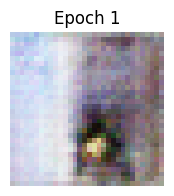

Epoch [1/10] Batch [0/782]                         Critic Loss: -3.7088 Generator Loss: 14.4311


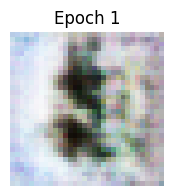

Epoch [1/10] Batch [0/782]                         Critic Loss: -3.7088 Generator Loss: 13.8894


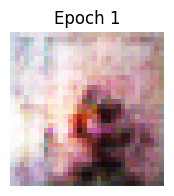

End of Epoch 1 | Critic Loss: -3.7088 | Generator Loss: 13.8894
End of Epoch 1 | Critic Loss: -4.3404 | Generator Loss: 14.0974
End of Epoch 1 | Critic Loss: -3.6604 | Generator Loss: 16.6171
End of Epoch 1 | Critic Loss: -3.4827 | Generator Loss: 16.5877
End of Epoch 1 | Critic Loss: -3.8048 | Generator Loss: 14.0694
End of Epoch 1 | Critic Loss: -3.9344 | Generator Loss: 14.1847
End of Epoch 1 | Critic Loss: -4.1477 | Generator Loss: 12.9424
End of Epoch 1 | Critic Loss: -3.4179 | Generator Loss: 14.7448
End of Epoch 1 | Critic Loss: -3.4541 | Generator Loss: 15.5014
End of Epoch 1 | Critic Loss: -3.7395 | Generator Loss: 14.4932
End of Epoch 1 | Critic Loss: -4.4218 | Generator Loss: 13.1760
End of Epoch 1 | Critic Loss: -4.8820 | Generator Loss: 15.2995
End of Epoch 1 | Critic Loss: -3.6165 | Generator Loss: 16.8128
End of Epoch 1 | Critic Loss: -3.9782 | Generator Loss: 16.7932
End of Epoch 1 | Critic Loss: -3.1291 | Generator Loss: 17.5665
End of Epoch 1 | Critic Loss: -4.0104 | 

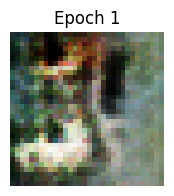

Epoch [1/10] Batch [200/782]                         Critic Loss: -3.4296 Generator Loss: 12.9029


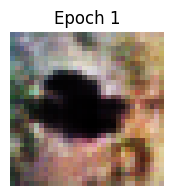

Epoch [1/10] Batch [200/782]                         Critic Loss: -3.4296 Generator Loss: 12.3315


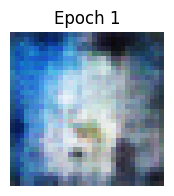

End of Epoch 1 | Critic Loss: -3.4296 | Generator Loss: 12.3315
End of Epoch 1 | Critic Loss: -3.1050 | Generator Loss: 12.5846
End of Epoch 1 | Critic Loss: -4.4874 | Generator Loss: 12.6342
End of Epoch 1 | Critic Loss: -4.6595 | Generator Loss: 10.0574
End of Epoch 1 | Critic Loss: -4.1374 | Generator Loss: 10.4520
End of Epoch 1 | Critic Loss: -3.0190 | Generator Loss: 11.4711
End of Epoch 1 | Critic Loss: -3.9648 | Generator Loss: 12.2623
End of Epoch 1 | Critic Loss: -2.3849 | Generator Loss: 13.2159
End of Epoch 1 | Critic Loss: -3.0323 | Generator Loss: 12.7691
End of Epoch 1 | Critic Loss: -4.0620 | Generator Loss: 10.6227
End of Epoch 1 | Critic Loss: -2.7928 | Generator Loss: 12.6179
End of Epoch 1 | Critic Loss: -3.5632 | Generator Loss: 12.4850
End of Epoch 1 | Critic Loss: -3.2904 | Generator Loss: 12.5924
End of Epoch 1 | Critic Loss: -3.2034 | Generator Loss: 13.0604
End of Epoch 1 | Critic Loss: -4.4557 | Generator Loss: 11.6028
End of Epoch 1 | Critic Loss: -4.8629 | 

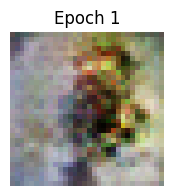

Epoch [1/10] Batch [400/782]                         Critic Loss: -3.6337 Generator Loss: 11.5296


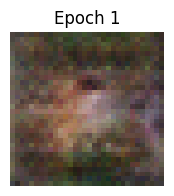

Epoch [1/10] Batch [400/782]                         Critic Loss: -3.6337 Generator Loss: 11.1155


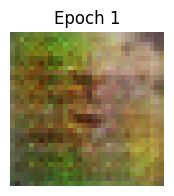

End of Epoch 1 | Critic Loss: -3.6337 | Generator Loss: 11.1155
End of Epoch 1 | Critic Loss: -2.8808 | Generator Loss: 9.4697
End of Epoch 1 | Critic Loss: -3.1182 | Generator Loss: 10.9601
End of Epoch 1 | Critic Loss: -3.5524 | Generator Loss: 11.2284
End of Epoch 1 | Critic Loss: -2.8422 | Generator Loss: 10.5039
End of Epoch 1 | Critic Loss: -4.1442 | Generator Loss: 11.1707
End of Epoch 1 | Critic Loss: -3.5895 | Generator Loss: 12.1411
End of Epoch 1 | Critic Loss: -3.7380 | Generator Loss: 11.8361
End of Epoch 1 | Critic Loss: -2.8655 | Generator Loss: 10.5908
End of Epoch 1 | Critic Loss: -4.6899 | Generator Loss: 7.1000
End of Epoch 1 | Critic Loss: -2.6866 | Generator Loss: 6.9908
End of Epoch 1 | Critic Loss: -3.7335 | Generator Loss: 6.1445
End of Epoch 1 | Critic Loss: -2.9156 | Generator Loss: 6.8671
End of Epoch 1 | Critic Loss: -4.2673 | Generator Loss: 11.1176
End of Epoch 1 | Critic Loss: -3.4817 | Generator Loss: 12.9119
End of Epoch 1 | Critic Loss: -3.5552 | Gener

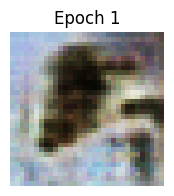

Epoch [1/10] Batch [600/782]                         Critic Loss: -3.9969 Generator Loss: 6.3502


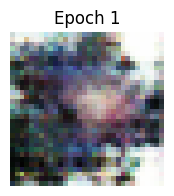

Epoch [1/10] Batch [600/782]                         Critic Loss: -3.9969 Generator Loss: 4.5263


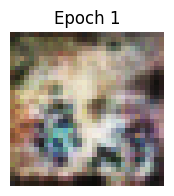

End of Epoch 1 | Critic Loss: -3.9969 | Generator Loss: 4.5263
End of Epoch 1 | Critic Loss: -4.5865 | Generator Loss: 9.9697
End of Epoch 1 | Critic Loss: -3.6847 | Generator Loss: 8.0417
End of Epoch 1 | Critic Loss: -3.2712 | Generator Loss: 6.7537
End of Epoch 1 | Critic Loss: -3.4928 | Generator Loss: 8.0273
End of Epoch 1 | Critic Loss: -2.9544 | Generator Loss: 9.7195
End of Epoch 1 | Critic Loss: -3.4282 | Generator Loss: 8.6966
End of Epoch 1 | Critic Loss: -2.8234 | Generator Loss: 7.2429
End of Epoch 1 | Critic Loss: -2.7321 | Generator Loss: 7.7892
End of Epoch 1 | Critic Loss: -4.2840 | Generator Loss: 7.5231
End of Epoch 1 | Critic Loss: -3.2520 | Generator Loss: 7.4673
End of Epoch 1 | Critic Loss: -3.4925 | Generator Loss: 7.4521
End of Epoch 1 | Critic Loss: -3.5261 | Generator Loss: 7.7127
End of Epoch 1 | Critic Loss: -4.2221 | Generator Loss: 6.7657
End of Epoch 1 | Critic Loss: -2.8993 | Generator Loss: 8.9215
End of Epoch 1 | Critic Loss: -2.7589 | Generator Loss:

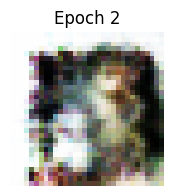

Epoch [2/10] Batch [0/782]                         Critic Loss: -3.2901 Generator Loss: 10.5423


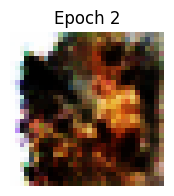

Epoch [2/10] Batch [0/782]                         Critic Loss: -3.2901 Generator Loss: 9.7160


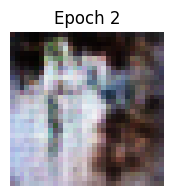

End of Epoch 2 | Critic Loss: -3.2901 | Generator Loss: 9.7160
End of Epoch 2 | Critic Loss: -2.9057 | Generator Loss: 9.1097
End of Epoch 2 | Critic Loss: -4.3473 | Generator Loss: 5.0834
End of Epoch 2 | Critic Loss: -3.1806 | Generator Loss: 4.5676
End of Epoch 2 | Critic Loss: -3.5192 | Generator Loss: 6.0575
End of Epoch 2 | Critic Loss: -2.4114 | Generator Loss: 8.5914
End of Epoch 2 | Critic Loss: -3.3398 | Generator Loss: 6.5009
End of Epoch 2 | Critic Loss: -3.6962 | Generator Loss: 4.5653
End of Epoch 2 | Critic Loss: -3.0179 | Generator Loss: 5.6167
End of Epoch 2 | Critic Loss: -5.3546 | Generator Loss: 1.9356
End of Epoch 2 | Critic Loss: -3.5214 | Generator Loss: 2.2824
End of Epoch 2 | Critic Loss: -3.9796 | Generator Loss: 2.6453
End of Epoch 2 | Critic Loss: -3.4835 | Generator Loss: 5.4577
End of Epoch 2 | Critic Loss: -3.4690 | Generator Loss: 4.1502
End of Epoch 2 | Critic Loss: -2.5018 | Generator Loss: 3.8002
End of Epoch 2 | Critic Loss: -2.5846 | Generator Loss:

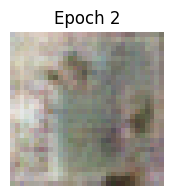

Epoch [2/10] Batch [200/782]                         Critic Loss: -2.9630 Generator Loss: 0.7251


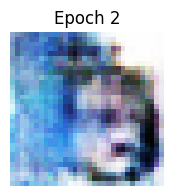

Epoch [2/10] Batch [200/782]                         Critic Loss: -2.9630 Generator Loss: 0.5721


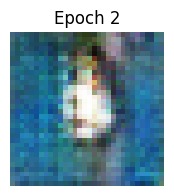

End of Epoch 2 | Critic Loss: -2.9630 | Generator Loss: 0.5721
End of Epoch 2 | Critic Loss: -3.5322 | Generator Loss: 0.9727
End of Epoch 2 | Critic Loss: -3.6777 | Generator Loss: 0.0076
End of Epoch 2 | Critic Loss: -3.2855 | Generator Loss: 2.5880
End of Epoch 2 | Critic Loss: -2.6733 | Generator Loss: 4.6683
End of Epoch 2 | Critic Loss: -3.7235 | Generator Loss: 3.9450
End of Epoch 2 | Critic Loss: -3.1837 | Generator Loss: 3.6492
End of Epoch 2 | Critic Loss: -3.2510 | Generator Loss: 2.4648
End of Epoch 2 | Critic Loss: -3.1677 | Generator Loss: 4.6716
End of Epoch 2 | Critic Loss: -3.3110 | Generator Loss: 2.9982
End of Epoch 2 | Critic Loss: -4.2790 | Generator Loss: 2.6784
End of Epoch 2 | Critic Loss: -4.0237 | Generator Loss: 1.6889
End of Epoch 2 | Critic Loss: -3.7682 | Generator Loss: 0.4469
End of Epoch 2 | Critic Loss: -3.8769 | Generator Loss: 0.1914
End of Epoch 2 | Critic Loss: -3.3886 | Generator Loss: 1.0954
End of Epoch 2 | Critic Loss: -2.6747 | Generator Loss:

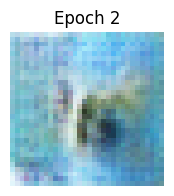

Epoch [2/10] Batch [400/782]                         Critic Loss: -2.6889 Generator Loss: 3.8002


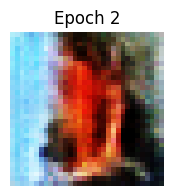

Epoch [2/10] Batch [400/782]                         Critic Loss: -2.6889 Generator Loss: 3.4291


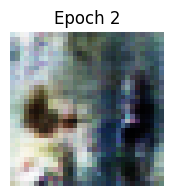

End of Epoch 2 | Critic Loss: -2.6889 | Generator Loss: 3.4291
End of Epoch 2 | Critic Loss: -3.1512 | Generator Loss: 1.8407
End of Epoch 2 | Critic Loss: -2.9745 | Generator Loss: 0.8873
End of Epoch 2 | Critic Loss: -4.0826 | Generator Loss: -1.9366
End of Epoch 2 | Critic Loss: -2.4521 | Generator Loss: -0.6671
End of Epoch 2 | Critic Loss: -3.8417 | Generator Loss: 1.5371
End of Epoch 2 | Critic Loss: -2.6661 | Generator Loss: 1.2323
End of Epoch 2 | Critic Loss: -2.6552 | Generator Loss: 1.4465
End of Epoch 2 | Critic Loss: -3.4522 | Generator Loss: 2.4563
End of Epoch 2 | Critic Loss: -3.7888 | Generator Loss: 2.7286
End of Epoch 2 | Critic Loss: -3.9878 | Generator Loss: 0.9829
End of Epoch 2 | Critic Loss: -2.6673 | Generator Loss: 0.9908
End of Epoch 2 | Critic Loss: -2.3637 | Generator Loss: -0.3709
End of Epoch 2 | Critic Loss: -3.9322 | Generator Loss: -2.3615
End of Epoch 2 | Critic Loss: -3.2661 | Generator Loss: 0.3098
End of Epoch 2 | Critic Loss: -3.5665 | Generator L

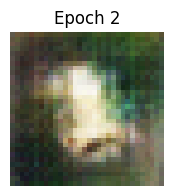

Epoch [2/10] Batch [600/782]                         Critic Loss: -2.6966 Generator Loss: -2.7122


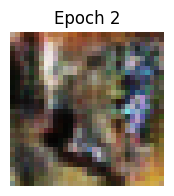

Epoch [2/10] Batch [600/782]                         Critic Loss: -2.6966 Generator Loss: -2.5309


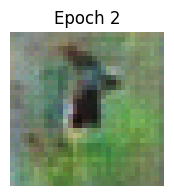

End of Epoch 2 | Critic Loss: -2.6966 | Generator Loss: -2.5309
End of Epoch 2 | Critic Loss: -3.6812 | Generator Loss: -2.0733
End of Epoch 2 | Critic Loss: -2.3298 | Generator Loss: -0.7315
End of Epoch 2 | Critic Loss: -2.5196 | Generator Loss: -2.4319
End of Epoch 2 | Critic Loss: -3.5166 | Generator Loss: -1.9649
End of Epoch 2 | Critic Loss: -2.7951 | Generator Loss: -4.2334
End of Epoch 2 | Critic Loss: -2.2536 | Generator Loss: -0.3455
End of Epoch 2 | Critic Loss: -2.3747 | Generator Loss: -2.2940
End of Epoch 2 | Critic Loss: -4.4361 | Generator Loss: -2.0316
End of Epoch 2 | Critic Loss: -2.9526 | Generator Loss: 1.7122
End of Epoch 2 | Critic Loss: -2.9504 | Generator Loss: 0.3956
End of Epoch 2 | Critic Loss: -3.0321 | Generator Loss: -0.1812
End of Epoch 2 | Critic Loss: -2.7417 | Generator Loss: -0.9097
End of Epoch 2 | Critic Loss: -2.9003 | Generator Loss: -1.6957
End of Epoch 2 | Critic Loss: -3.1172 | Generator Loss: -1.7965
End of Epoch 2 | Critic Loss: -3.6577 | Ge

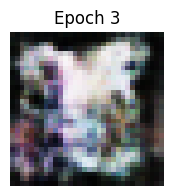

Epoch [3/10] Batch [0/782]                         Critic Loss: -3.0953 Generator Loss: -2.7889


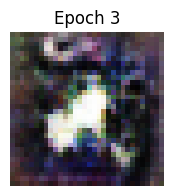

Epoch [3/10] Batch [0/782]                         Critic Loss: -3.0953 Generator Loss: -3.6375


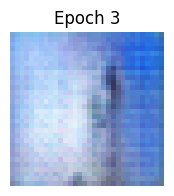

End of Epoch 3 | Critic Loss: -3.0953 | Generator Loss: -3.6375
End of Epoch 3 | Critic Loss: -2.7568 | Generator Loss: -2.1986
End of Epoch 3 | Critic Loss: -3.6048 | Generator Loss: -0.0334
End of Epoch 3 | Critic Loss: -3.3356 | Generator Loss: 0.3066
End of Epoch 3 | Critic Loss: -2.8726 | Generator Loss: -0.3927
End of Epoch 3 | Critic Loss: -2.5222 | Generator Loss: 0.0157
End of Epoch 3 | Critic Loss: -3.3233 | Generator Loss: -2.4745
End of Epoch 3 | Critic Loss: -3.4323 | Generator Loss: -2.4659
End of Epoch 3 | Critic Loss: -4.9447 | Generator Loss: -3.7993
End of Epoch 3 | Critic Loss: -3.2813 | Generator Loss: -1.8395
End of Epoch 3 | Critic Loss: -2.7684 | Generator Loss: -1.2030
End of Epoch 3 | Critic Loss: -2.7317 | Generator Loss: -3.9575
End of Epoch 3 | Critic Loss: -2.7841 | Generator Loss: -1.6375
End of Epoch 3 | Critic Loss: -3.6684 | Generator Loss: -1.7626
End of Epoch 3 | Critic Loss: -2.8627 | Generator Loss: -2.1540
End of Epoch 3 | Critic Loss: -3.8243 | Ge

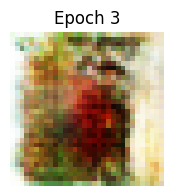

Epoch [3/10] Batch [200/782]                         Critic Loss: -4.3777 Generator Loss: -1.4904


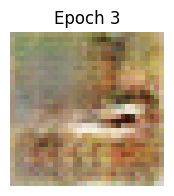

Epoch [3/10] Batch [200/782]                         Critic Loss: -4.3777 Generator Loss: -1.9827


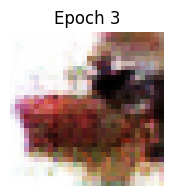

End of Epoch 3 | Critic Loss: -4.3777 | Generator Loss: -1.9827
End of Epoch 3 | Critic Loss: -3.8507 | Generator Loss: -4.1405
End of Epoch 3 | Critic Loss: -2.6110 | Generator Loss: -3.4078
End of Epoch 3 | Critic Loss: -2.3546 | Generator Loss: -2.6344
End of Epoch 3 | Critic Loss: -2.5224 | Generator Loss: -4.3172
End of Epoch 3 | Critic Loss: -2.7619 | Generator Loss: -2.5262
End of Epoch 3 | Critic Loss: -4.3630 | Generator Loss: -4.1607
End of Epoch 3 | Critic Loss: -3.1992 | Generator Loss: -6.4826
End of Epoch 3 | Critic Loss: -2.9912 | Generator Loss: -3.9408
End of Epoch 3 | Critic Loss: -2.6658 | Generator Loss: -2.7171
End of Epoch 3 | Critic Loss: -3.0943 | Generator Loss: -1.9290
End of Epoch 3 | Critic Loss: -3.2836 | Generator Loss: -0.5481
End of Epoch 3 | Critic Loss: -3.4935 | Generator Loss: 0.5454
End of Epoch 3 | Critic Loss: -2.8193 | Generator Loss: -0.5872
End of Epoch 3 | Critic Loss: -3.3542 | Generator Loss: -1.9107
End of Epoch 3 | Critic Loss: -2.9236 | G

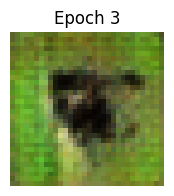

Epoch [3/10] Batch [400/782]                         Critic Loss: -4.3264 Generator Loss: -4.7983


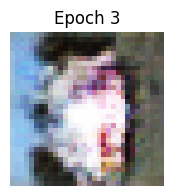

Epoch [3/10] Batch [400/782]                         Critic Loss: -4.3264 Generator Loss: -6.4987


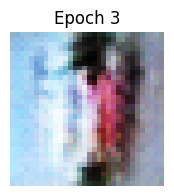

End of Epoch 3 | Critic Loss: -4.3264 | Generator Loss: -6.4987
End of Epoch 3 | Critic Loss: -3.4201 | Generator Loss: -6.3390
End of Epoch 3 | Critic Loss: -2.8410 | Generator Loss: -4.4157
End of Epoch 3 | Critic Loss: -2.4017 | Generator Loss: -5.0539
End of Epoch 3 | Critic Loss: -3.7364 | Generator Loss: -4.9237
End of Epoch 3 | Critic Loss: -3.5987 | Generator Loss: -2.3762
End of Epoch 3 | Critic Loss: -5.1591 | Generator Loss: -2.9621
End of Epoch 3 | Critic Loss: -3.0020 | Generator Loss: -7.9222
End of Epoch 3 | Critic Loss: -2.9933 | Generator Loss: -5.0553
End of Epoch 3 | Critic Loss: -2.8966 | Generator Loss: -2.3841
End of Epoch 3 | Critic Loss: -2.3286 | Generator Loss: -2.7361
End of Epoch 3 | Critic Loss: -3.1271 | Generator Loss: -5.6859
End of Epoch 3 | Critic Loss: -4.0408 | Generator Loss: -8.0425
End of Epoch 3 | Critic Loss: -2.7722 | Generator Loss: -6.6011
End of Epoch 3 | Critic Loss: -3.9600 | Generator Loss: -6.0782
End of Epoch 3 | Critic Loss: -3.3517 | 

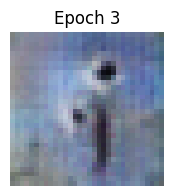

Epoch [3/10] Batch [600/782]                         Critic Loss: -2.4870 Generator Loss: -4.2931


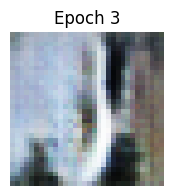

Epoch [3/10] Batch [600/782]                         Critic Loss: -2.4870 Generator Loss: -4.9249


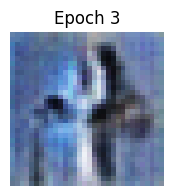

End of Epoch 3 | Critic Loss: -2.4870 | Generator Loss: -4.9249
End of Epoch 3 | Critic Loss: -3.9922 | Generator Loss: -8.3712
End of Epoch 3 | Critic Loss: -2.6131 | Generator Loss: -7.9892
End of Epoch 3 | Critic Loss: -2.5790 | Generator Loss: -4.4541
End of Epoch 3 | Critic Loss: -2.7528 | Generator Loss: -3.4542
End of Epoch 3 | Critic Loss: -3.1844 | Generator Loss: -4.5270
End of Epoch 3 | Critic Loss: -2.6824 | Generator Loss: -5.9208
End of Epoch 3 | Critic Loss: -3.8627 | Generator Loss: -5.8794
End of Epoch 3 | Critic Loss: -3.9201 | Generator Loss: -5.0757
End of Epoch 3 | Critic Loss: -2.9884 | Generator Loss: -8.0356
End of Epoch 3 | Critic Loss: -3.5172 | Generator Loss: -5.1999
End of Epoch 3 | Critic Loss: -2.8769 | Generator Loss: -4.2223
End of Epoch 3 | Critic Loss: -3.3202 | Generator Loss: -7.0899
End of Epoch 3 | Critic Loss: -3.1729 | Generator Loss: -6.5493
End of Epoch 3 | Critic Loss: -2.2110 | Generator Loss: -4.3270
End of Epoch 3 | Critic Loss: -2.9480 | 

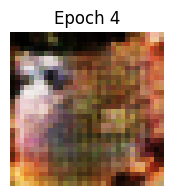

Epoch [4/10] Batch [0/782]                         Critic Loss: -2.3738 Generator Loss: -7.7329


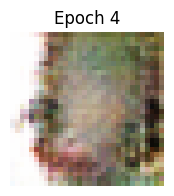

Epoch [4/10] Batch [0/782]                         Critic Loss: -2.3738 Generator Loss: -7.4890


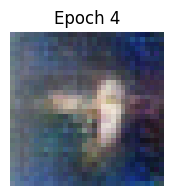

End of Epoch 4 | Critic Loss: -2.3738 | Generator Loss: -7.4890
End of Epoch 4 | Critic Loss: -2.5641 | Generator Loss: -6.6676
End of Epoch 4 | Critic Loss: -3.1376 | Generator Loss: -5.2424
End of Epoch 4 | Critic Loss: -1.5530 | Generator Loss: -3.4565
End of Epoch 4 | Critic Loss: -2.7751 | Generator Loss: -5.4623
End of Epoch 4 | Critic Loss: -2.7669 | Generator Loss: -4.9595
End of Epoch 4 | Critic Loss: -2.2815 | Generator Loss: -4.9649
End of Epoch 4 | Critic Loss: -3.4967 | Generator Loss: -3.0039
End of Epoch 4 | Critic Loss: -3.8156 | Generator Loss: -6.2286
End of Epoch 4 | Critic Loss: -3.4338 | Generator Loss: -3.5549
End of Epoch 4 | Critic Loss: -4.6511 | Generator Loss: -6.7406
End of Epoch 4 | Critic Loss: -3.3026 | Generator Loss: -3.7568
End of Epoch 4 | Critic Loss: -2.5518 | Generator Loss: -3.8746
End of Epoch 4 | Critic Loss: -2.2706 | Generator Loss: -6.1870
End of Epoch 4 | Critic Loss: -3.1490 | Generator Loss: -6.5574
End of Epoch 4 | Critic Loss: -2.4652 | 

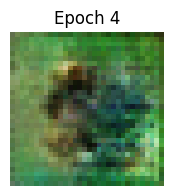

Epoch [4/10] Batch [200/782]                         Critic Loss: -4.1657 Generator Loss: -7.4290


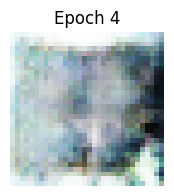

Epoch [4/10] Batch [200/782]                         Critic Loss: -4.1657 Generator Loss: -8.1597


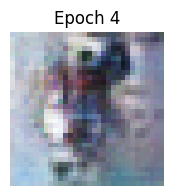

End of Epoch 4 | Critic Loss: -4.1657 | Generator Loss: -8.1597
End of Epoch 4 | Critic Loss: -4.0806 | Generator Loss: -10.8485
End of Epoch 4 | Critic Loss: -2.9109 | Generator Loss: -7.6696
End of Epoch 4 | Critic Loss: -3.3790 | Generator Loss: -5.7634
End of Epoch 4 | Critic Loss: -3.3673 | Generator Loss: -5.8582
End of Epoch 4 | Critic Loss: -2.8979 | Generator Loss: -7.7772
End of Epoch 4 | Critic Loss: -2.7396 | Generator Loss: -6.8854
End of Epoch 4 | Critic Loss: -3.6620 | Generator Loss: -6.8868
End of Epoch 4 | Critic Loss: -2.8264 | Generator Loss: -5.4138
End of Epoch 4 | Critic Loss: -3.6571 | Generator Loss: -5.9268
End of Epoch 4 | Critic Loss: -2.7161 | Generator Loss: -8.6212
End of Epoch 4 | Critic Loss: -2.3992 | Generator Loss: -6.3876
End of Epoch 4 | Critic Loss: -2.6820 | Generator Loss: -7.2557
End of Epoch 4 | Critic Loss: -3.5155 | Generator Loss: -10.1645
End of Epoch 4 | Critic Loss: -3.2746 | Generator Loss: -9.4000
End of Epoch 4 | Critic Loss: -3.9830 

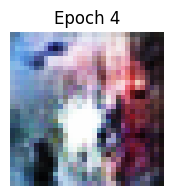

Epoch [4/10] Batch [400/782]                         Critic Loss: -3.6580 Generator Loss: -8.7202


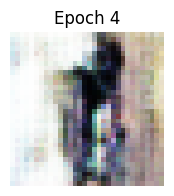

Epoch [4/10] Batch [400/782]                         Critic Loss: -3.6580 Generator Loss: -8.9375


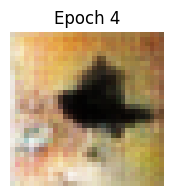

End of Epoch 4 | Critic Loss: -3.6580 | Generator Loss: -8.9375
End of Epoch 4 | Critic Loss: -2.9015 | Generator Loss: -8.2943
End of Epoch 4 | Critic Loss: -3.3202 | Generator Loss: -8.1754
End of Epoch 4 | Critic Loss: -2.8125 | Generator Loss: -8.4914
End of Epoch 4 | Critic Loss: -4.0141 | Generator Loss: -6.1825
End of Epoch 4 | Critic Loss: -3.1389 | Generator Loss: -6.8903
End of Epoch 4 | Critic Loss: -1.7547 | Generator Loss: -7.2645
End of Epoch 4 | Critic Loss: -3.5544 | Generator Loss: -9.2065
End of Epoch 4 | Critic Loss: -3.4257 | Generator Loss: -7.8470
End of Epoch 4 | Critic Loss: -2.8230 | Generator Loss: -9.1165
End of Epoch 4 | Critic Loss: -3.7501 | Generator Loss: -10.3353
End of Epoch 4 | Critic Loss: -3.4364 | Generator Loss: -10.1856
End of Epoch 4 | Critic Loss: -2.6713 | Generator Loss: -10.5964
End of Epoch 4 | Critic Loss: -4.0748 | Generator Loss: -6.1353
End of Epoch 4 | Critic Loss: -2.0920 | Generator Loss: -8.9733
End of Epoch 4 | Critic Loss: -2.9166

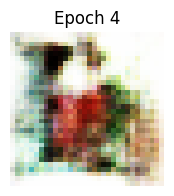

Epoch [4/10] Batch [600/782]                         Critic Loss: -2.7325 Generator Loss: -7.4756


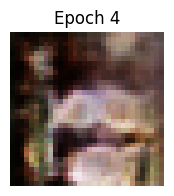

Epoch [4/10] Batch [600/782]                         Critic Loss: -2.7325 Generator Loss: -7.4255


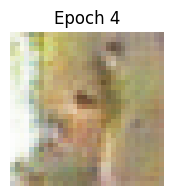

End of Epoch 4 | Critic Loss: -2.7325 | Generator Loss: -7.4255
End of Epoch 4 | Critic Loss: -2.1759 | Generator Loss: -8.0485
End of Epoch 4 | Critic Loss: -2.4952 | Generator Loss: -5.8604
End of Epoch 4 | Critic Loss: -2.7100 | Generator Loss: -10.7429
End of Epoch 4 | Critic Loss: -3.6131 | Generator Loss: -6.4789
End of Epoch 4 | Critic Loss: -2.9336 | Generator Loss: -5.5273
End of Epoch 4 | Critic Loss: -3.0852 | Generator Loss: -8.2309
End of Epoch 4 | Critic Loss: -3.2203 | Generator Loss: -10.6470
End of Epoch 4 | Critic Loss: -3.0378 | Generator Loss: -8.6957
End of Epoch 4 | Critic Loss: -2.3262 | Generator Loss: -10.0476
End of Epoch 4 | Critic Loss: -3.2576 | Generator Loss: -11.1985
End of Epoch 4 | Critic Loss: -2.7878 | Generator Loss: -11.0817
End of Epoch 4 | Critic Loss: -3.8916 | Generator Loss: -6.4705
End of Epoch 4 | Critic Loss: -3.1883 | Generator Loss: -6.5109
End of Epoch 4 | Critic Loss: -2.2697 | Generator Loss: -7.0580
End of Epoch 4 | Critic Loss: -3.66

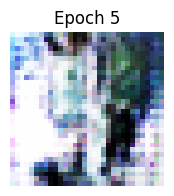

Epoch [5/10] Batch [0/782]                         Critic Loss: -3.6196 Generator Loss: -8.5408


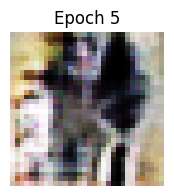

Epoch [5/10] Batch [0/782]                         Critic Loss: -3.6196 Generator Loss: -8.8058


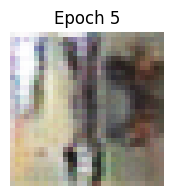

End of Epoch 5 | Critic Loss: -3.6196 | Generator Loss: -8.8058
End of Epoch 5 | Critic Loss: -3.2377 | Generator Loss: -9.8513
End of Epoch 5 | Critic Loss: -2.3678 | Generator Loss: -8.1551
End of Epoch 5 | Critic Loss: -1.9212 | Generator Loss: -6.5089
End of Epoch 5 | Critic Loss: -2.7311 | Generator Loss: -7.4597
End of Epoch 5 | Critic Loss: -2.9081 | Generator Loss: -8.6553
End of Epoch 5 | Critic Loss: -3.9429 | Generator Loss: -9.9946
End of Epoch 5 | Critic Loss: -3.1448 | Generator Loss: -11.3843
End of Epoch 5 | Critic Loss: -3.8946 | Generator Loss: -12.9663
End of Epoch 5 | Critic Loss: -3.3567 | Generator Loss: -8.4580
End of Epoch 5 | Critic Loss: -3.3171 | Generator Loss: -8.3220
End of Epoch 5 | Critic Loss: -3.5316 | Generator Loss: -10.6855
End of Epoch 5 | Critic Loss: -2.9650 | Generator Loss: -10.4070
End of Epoch 5 | Critic Loss: -2.5978 | Generator Loss: -9.1168
End of Epoch 5 | Critic Loss: -3.2996 | Generator Loss: -7.0320
End of Epoch 5 | Critic Loss: -3.352

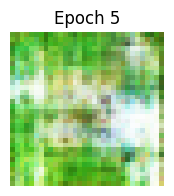

Epoch [5/10] Batch [200/782]                         Critic Loss: -2.7993 Generator Loss: -8.8678


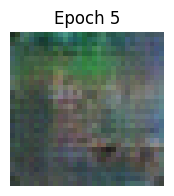

Epoch [5/10] Batch [200/782]                         Critic Loss: -2.7993 Generator Loss: -8.2832


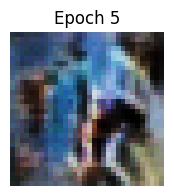

End of Epoch 5 | Critic Loss: -2.7993 | Generator Loss: -8.2832
End of Epoch 5 | Critic Loss: -2.6123 | Generator Loss: -8.8850
End of Epoch 5 | Critic Loss: -2.8936 | Generator Loss: -10.2420
End of Epoch 5 | Critic Loss: -3.9660 | Generator Loss: -12.0256
End of Epoch 5 | Critic Loss: -2.4628 | Generator Loss: -9.7690
End of Epoch 5 | Critic Loss: -2.4245 | Generator Loss: -9.9719
End of Epoch 5 | Critic Loss: -3.5501 | Generator Loss: -12.4514
End of Epoch 5 | Critic Loss: -2.9814 | Generator Loss: -8.2260
End of Epoch 5 | Critic Loss: -4.5308 | Generator Loss: -8.0756
End of Epoch 5 | Critic Loss: -2.7483 | Generator Loss: -7.2508
End of Epoch 5 | Critic Loss: -2.3323 | Generator Loss: -8.5589
End of Epoch 5 | Critic Loss: -3.1595 | Generator Loss: -10.0713
End of Epoch 5 | Critic Loss: -2.9290 | Generator Loss: -11.3558
End of Epoch 5 | Critic Loss: -2.7660 | Generator Loss: -8.8373
End of Epoch 5 | Critic Loss: -3.8272 | Generator Loss: -8.9847
End of Epoch 5 | Critic Loss: -2.76

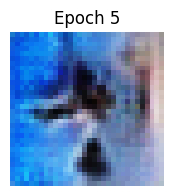

Epoch [5/10] Batch [400/782]                         Critic Loss: -3.9038 Generator Loss: -7.9194


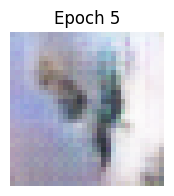

Epoch [5/10] Batch [400/782]                         Critic Loss: -3.9038 Generator Loss: -8.8459


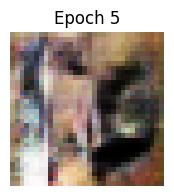

End of Epoch 5 | Critic Loss: -3.9038 | Generator Loss: -8.8459
End of Epoch 5 | Critic Loss: -4.9321 | Generator Loss: -11.9175
End of Epoch 5 | Critic Loss: -3.1715 | Generator Loss: -9.5741
End of Epoch 5 | Critic Loss: -2.6607 | Generator Loss: -9.8662
End of Epoch 5 | Critic Loss: -3.1859 | Generator Loss: -7.2749
End of Epoch 5 | Critic Loss: -3.2779 | Generator Loss: -6.1255
End of Epoch 5 | Critic Loss: -2.8762 | Generator Loss: -8.4121
End of Epoch 5 | Critic Loss: -3.0502 | Generator Loss: -10.5434
End of Epoch 5 | Critic Loss: -3.9547 | Generator Loss: -10.7551
End of Epoch 5 | Critic Loss: -3.4431 | Generator Loss: -10.6749
End of Epoch 5 | Critic Loss: -3.0118 | Generator Loss: -9.7072
End of Epoch 5 | Critic Loss: -2.8630 | Generator Loss: -10.5203
End of Epoch 5 | Critic Loss: -2.4333 | Generator Loss: -7.8815
End of Epoch 5 | Critic Loss: -4.0900 | Generator Loss: -14.0690
End of Epoch 5 | Critic Loss: -3.8479 | Generator Loss: -14.5817
End of Epoch 5 | Critic Loss: -3.

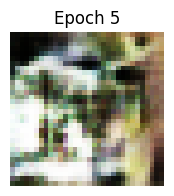

Epoch [5/10] Batch [600/782]                         Critic Loss: -2.3460 Generator Loss: -10.2265


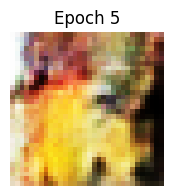

Epoch [5/10] Batch [600/782]                         Critic Loss: -2.3460 Generator Loss: -11.1561


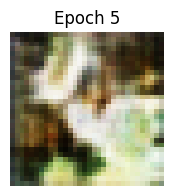

End of Epoch 5 | Critic Loss: -2.3460 | Generator Loss: -11.1561
End of Epoch 5 | Critic Loss: -3.8744 | Generator Loss: -8.3415
End of Epoch 5 | Critic Loss: -1.3154 | Generator Loss: -9.5457
End of Epoch 5 | Critic Loss: -3.2413 | Generator Loss: -12.4093
End of Epoch 5 | Critic Loss: -3.0998 | Generator Loss: -8.4266
End of Epoch 5 | Critic Loss: -3.1236 | Generator Loss: -8.8568
End of Epoch 5 | Critic Loss: -2.5938 | Generator Loss: -12.6064
End of Epoch 5 | Critic Loss: -2.5833 | Generator Loss: -12.2956
End of Epoch 5 | Critic Loss: -3.0104 | Generator Loss: -9.6475
End of Epoch 5 | Critic Loss: -5.0080 | Generator Loss: -6.2333
End of Epoch 5 | Critic Loss: -4.1358 | Generator Loss: -9.1733
End of Epoch 5 | Critic Loss: -3.2465 | Generator Loss: -12.3523
End of Epoch 5 | Critic Loss: -2.9294 | Generator Loss: -10.5617
End of Epoch 5 | Critic Loss: -3.3323 | Generator Loss: -12.1010
End of Epoch 5 | Critic Loss: -2.6354 | Generator Loss: -9.9721
End of Epoch 5 | Critic Loss: -3.

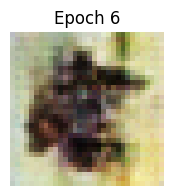

Epoch [6/10] Batch [0/782]                         Critic Loss: -3.0970 Generator Loss: -9.4041


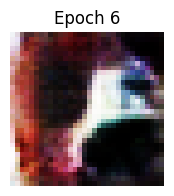

Epoch [6/10] Batch [0/782]                         Critic Loss: -3.0970 Generator Loss: -10.1826


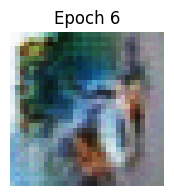

End of Epoch 6 | Critic Loss: -3.0970 | Generator Loss: -10.1826
End of Epoch 6 | Critic Loss: -2.1457 | Generator Loss: -9.8271
End of Epoch 6 | Critic Loss: -2.4750 | Generator Loss: -7.6299
End of Epoch 6 | Critic Loss: -2.7429 | Generator Loss: -10.1478
End of Epoch 6 | Critic Loss: -3.5600 | Generator Loss: -11.6515
End of Epoch 6 | Critic Loss: -3.3644 | Generator Loss: -9.9825
End of Epoch 6 | Critic Loss: -3.6438 | Generator Loss: -14.0813
End of Epoch 6 | Critic Loss: -2.7528 | Generator Loss: -11.9865
End of Epoch 6 | Critic Loss: -3.8896 | Generator Loss: -13.4424
End of Epoch 6 | Critic Loss: -3.2624 | Generator Loss: -10.8886
End of Epoch 6 | Critic Loss: -3.1397 | Generator Loss: -8.9264
End of Epoch 6 | Critic Loss: -3.3732 | Generator Loss: -6.0160
End of Epoch 6 | Critic Loss: -2.4452 | Generator Loss: -8.0591
End of Epoch 6 | Critic Loss: -2.7184 | Generator Loss: -11.8126
End of Epoch 6 | Critic Loss: -2.8712 | Generator Loss: -11.5895
End of Epoch 6 | Critic Loss: -

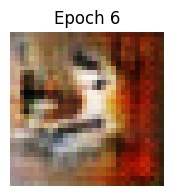

Epoch [6/10] Batch [200/782]                         Critic Loss: -2.1308 Generator Loss: -15.1923


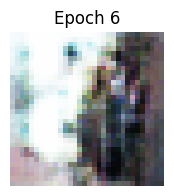

Epoch [6/10] Batch [200/782]                         Critic Loss: -2.1308 Generator Loss: -15.0971


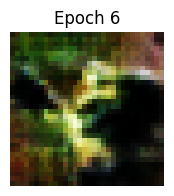

End of Epoch 6 | Critic Loss: -2.1308 | Generator Loss: -15.0971
End of Epoch 6 | Critic Loss: -1.9997 | Generator Loss: -14.2977
End of Epoch 6 | Critic Loss: -3.0515 | Generator Loss: -14.5050
End of Epoch 6 | Critic Loss: -2.4047 | Generator Loss: -14.0461
End of Epoch 6 | Critic Loss: -2.9571 | Generator Loss: -12.6771
End of Epoch 6 | Critic Loss: -3.1866 | Generator Loss: -10.2220
End of Epoch 6 | Critic Loss: -1.9209 | Generator Loss: -11.9886
End of Epoch 6 | Critic Loss: -2.5855 | Generator Loss: -9.8642
End of Epoch 6 | Critic Loss: -2.4396 | Generator Loss: -11.0172
End of Epoch 6 | Critic Loss: -3.3930 | Generator Loss: -16.1077
End of Epoch 6 | Critic Loss: -3.1772 | Generator Loss: -13.0979
End of Epoch 6 | Critic Loss: -3.8272 | Generator Loss: -14.4699
End of Epoch 6 | Critic Loss: -2.8601 | Generator Loss: -13.4266
End of Epoch 6 | Critic Loss: -3.2498 | Generator Loss: -14.8104
End of Epoch 6 | Critic Loss: -2.6739 | Generator Loss: -12.2291
End of Epoch 6 | Critic Lo

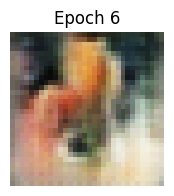

Epoch [6/10] Batch [400/782]                         Critic Loss: -3.8803 Generator Loss: -12.5281


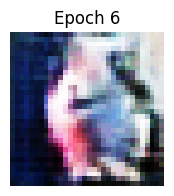

Epoch [6/10] Batch [400/782]                         Critic Loss: -3.8803 Generator Loss: -12.7611


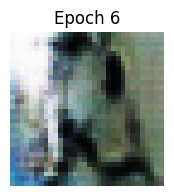

End of Epoch 6 | Critic Loss: -3.8803 | Generator Loss: -12.7611
End of Epoch 6 | Critic Loss: -2.6121 | Generator Loss: -14.1045
End of Epoch 6 | Critic Loss: -2.7269 | Generator Loss: -11.9603
End of Epoch 6 | Critic Loss: -3.4493 | Generator Loss: -13.0935
End of Epoch 6 | Critic Loss: -2.8976 | Generator Loss: -11.5975
End of Epoch 6 | Critic Loss: -3.2365 | Generator Loss: -10.8257
End of Epoch 6 | Critic Loss: -3.4498 | Generator Loss: -14.1085
End of Epoch 6 | Critic Loss: -2.8002 | Generator Loss: -13.8247
End of Epoch 6 | Critic Loss: -2.6497 | Generator Loss: -11.9947
End of Epoch 6 | Critic Loss: -4.2444 | Generator Loss: -11.8827
End of Epoch 6 | Critic Loss: -5.6622 | Generator Loss: -13.8782
End of Epoch 6 | Critic Loss: -2.4984 | Generator Loss: -12.6762
End of Epoch 6 | Critic Loss: -2.7113 | Generator Loss: -12.1415
End of Epoch 6 | Critic Loss: -3.5492 | Generator Loss: -12.8129
End of Epoch 6 | Critic Loss: -2.9543 | Generator Loss: -11.6194
End of Epoch 6 | Critic L

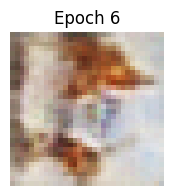

Epoch [6/10] Batch [600/782]                         Critic Loss: -4.1700 Generator Loss: -10.0843


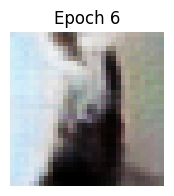

Epoch [6/10] Batch [600/782]                         Critic Loss: -4.1700 Generator Loss: -11.2689


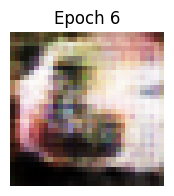

End of Epoch 6 | Critic Loss: -4.1700 | Generator Loss: -11.2689
End of Epoch 6 | Critic Loss: -3.3464 | Generator Loss: -14.0675
End of Epoch 6 | Critic Loss: -3.7316 | Generator Loss: -14.1780
End of Epoch 6 | Critic Loss: -3.2948 | Generator Loss: -12.5044
End of Epoch 6 | Critic Loss: -2.2121 | Generator Loss: -10.4989
End of Epoch 6 | Critic Loss: -2.7277 | Generator Loss: -10.0293
End of Epoch 6 | Critic Loss: -2.0002 | Generator Loss: -12.1229
End of Epoch 6 | Critic Loss: -3.8515 | Generator Loss: -14.9344
End of Epoch 6 | Critic Loss: -2.9384 | Generator Loss: -15.2931
End of Epoch 6 | Critic Loss: -3.8621 | Generator Loss: -19.4079
End of Epoch 6 | Critic Loss: -3.6775 | Generator Loss: -17.4869
End of Epoch 6 | Critic Loss: -1.9665 | Generator Loss: -13.3091
End of Epoch 6 | Critic Loss: -3.5582 | Generator Loss: -11.5999
End of Epoch 6 | Critic Loss: -4.6784 | Generator Loss: -13.6383
End of Epoch 6 | Critic Loss: -3.1051 | Generator Loss: -11.1577
End of Epoch 6 | Critic L

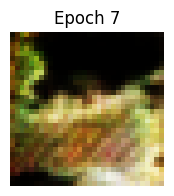

Epoch [7/10] Batch [0/782]                         Critic Loss: -3.1352 Generator Loss: -15.1394


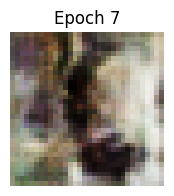

Epoch [7/10] Batch [0/782]                         Critic Loss: -3.1352 Generator Loss: -15.8741


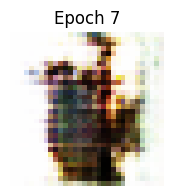

End of Epoch 7 | Critic Loss: -3.1352 | Generator Loss: -15.8741
End of Epoch 7 | Critic Loss: -2.6273 | Generator Loss: -16.1612
End of Epoch 7 | Critic Loss: -3.3255 | Generator Loss: -15.8053
End of Epoch 7 | Critic Loss: -5.2434 | Generator Loss: -16.0374
End of Epoch 7 | Critic Loss: -3.1590 | Generator Loss: -15.0174
End of Epoch 7 | Critic Loss: -2.5837 | Generator Loss: -9.4831
End of Epoch 7 | Critic Loss: -4.7334 | Generator Loss: -11.8462
End of Epoch 7 | Critic Loss: -2.9073 | Generator Loss: -12.4666
End of Epoch 7 | Critic Loss: -2.9154 | Generator Loss: -15.4082
End of Epoch 7 | Critic Loss: -2.3873 | Generator Loss: -14.1125
End of Epoch 7 | Critic Loss: -3.0312 | Generator Loss: -11.6190
End of Epoch 7 | Critic Loss: -2.8207 | Generator Loss: -9.2516
End of Epoch 7 | Critic Loss: -3.5132 | Generator Loss: -12.9766
End of Epoch 7 | Critic Loss: -4.0073 | Generator Loss: -15.0099
End of Epoch 7 | Critic Loss: -2.1595 | Generator Loss: -14.3705
End of Epoch 7 | Critic Los

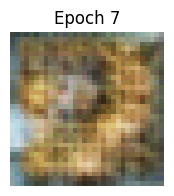

Epoch [7/10] Batch [200/782]                         Critic Loss: -2.3208 Generator Loss: -13.0840


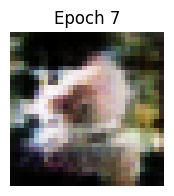

Epoch [7/10] Batch [200/782]                         Critic Loss: -2.3208 Generator Loss: -12.9694


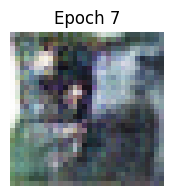

End of Epoch 7 | Critic Loss: -2.3208 | Generator Loss: -12.9694
End of Epoch 7 | Critic Loss: -3.0033 | Generator Loss: -14.8263
End of Epoch 7 | Critic Loss: -2.7360 | Generator Loss: -16.8536
End of Epoch 7 | Critic Loss: -2.4427 | Generator Loss: -14.4941
End of Epoch 7 | Critic Loss: -3.2996 | Generator Loss: -17.6975
End of Epoch 7 | Critic Loss: -3.7793 | Generator Loss: -15.7584
End of Epoch 7 | Critic Loss: -1.8748 | Generator Loss: -14.3455
End of Epoch 7 | Critic Loss: -2.2790 | Generator Loss: -15.0688
End of Epoch 7 | Critic Loss: -3.0946 | Generator Loss: -16.2818
End of Epoch 7 | Critic Loss: -3.3997 | Generator Loss: -15.6785
End of Epoch 7 | Critic Loss: -2.7828 | Generator Loss: -17.3581
End of Epoch 7 | Critic Loss: -2.9785 | Generator Loss: -14.1463
End of Epoch 7 | Critic Loss: -2.9066 | Generator Loss: -10.7391
End of Epoch 7 | Critic Loss: -3.5687 | Generator Loss: -11.5915
End of Epoch 7 | Critic Loss: -3.3114 | Generator Loss: -15.7541
End of Epoch 7 | Critic L

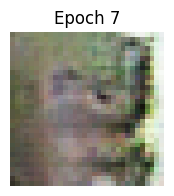

Epoch [7/10] Batch [400/782]                         Critic Loss: -2.8856 Generator Loss: -15.0925


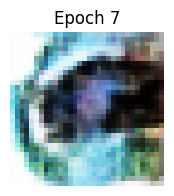

Epoch [7/10] Batch [400/782]                         Critic Loss: -2.8856 Generator Loss: -14.7865


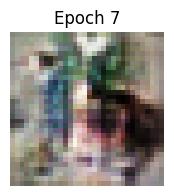

End of Epoch 7 | Critic Loss: -2.8856 | Generator Loss: -14.7865
End of Epoch 7 | Critic Loss: -3.1343 | Generator Loss: -12.8876
End of Epoch 7 | Critic Loss: -2.9888 | Generator Loss: -11.0138
End of Epoch 7 | Critic Loss: -2.7987 | Generator Loss: -12.6551
End of Epoch 7 | Critic Loss: -2.3453 | Generator Loss: -13.7818
End of Epoch 7 | Critic Loss: -2.9449 | Generator Loss: -13.9493
End of Epoch 7 | Critic Loss: -2.7720 | Generator Loss: -14.2467
End of Epoch 7 | Critic Loss: -4.2970 | Generator Loss: -13.9122
End of Epoch 7 | Critic Loss: -3.1208 | Generator Loss: -12.6027
End of Epoch 7 | Critic Loss: -3.3051 | Generator Loss: -12.6803
End of Epoch 7 | Critic Loss: -3.0781 | Generator Loss: -13.8037
End of Epoch 7 | Critic Loss: -3.7877 | Generator Loss: -10.3567
End of Epoch 7 | Critic Loss: -3.9498 | Generator Loss: -13.3900
End of Epoch 7 | Critic Loss: -4.6007 | Generator Loss: -13.0243
End of Epoch 7 | Critic Loss: -3.7191 | Generator Loss: -13.1206
End of Epoch 7 | Critic L

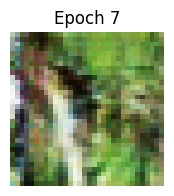

Epoch [7/10] Batch [600/782]                         Critic Loss: -4.8080 Generator Loss: -19.8708


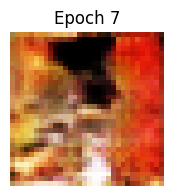

Epoch [7/10] Batch [600/782]                         Critic Loss: -4.8080 Generator Loss: -21.8512


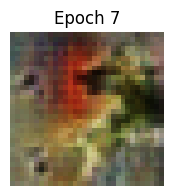

End of Epoch 7 | Critic Loss: -4.8080 | Generator Loss: -21.8512
End of Epoch 7 | Critic Loss: -3.8543 | Generator Loss: -18.3798
End of Epoch 7 | Critic Loss: -2.6024 | Generator Loss: -17.8436
End of Epoch 7 | Critic Loss: -3.2324 | Generator Loss: -15.7344
End of Epoch 7 | Critic Loss: -4.8568 | Generator Loss: -15.4256
End of Epoch 7 | Critic Loss: -2.2058 | Generator Loss: -11.6962
End of Epoch 7 | Critic Loss: -4.3563 | Generator Loss: -11.9237
End of Epoch 7 | Critic Loss: -3.0456 | Generator Loss: -15.5869
End of Epoch 7 | Critic Loss: -3.5864 | Generator Loss: -18.9693
End of Epoch 7 | Critic Loss: -2.5857 | Generator Loss: -18.5115
End of Epoch 7 | Critic Loss: -2.6581 | Generator Loss: -18.2762
End of Epoch 7 | Critic Loss: -3.3122 | Generator Loss: -15.4577
End of Epoch 7 | Critic Loss: -2.9053 | Generator Loss: -15.7920
End of Epoch 7 | Critic Loss: -2.9867 | Generator Loss: -18.8420
End of Epoch 7 | Critic Loss: -2.8976 | Generator Loss: -15.8595
End of Epoch 7 | Critic L

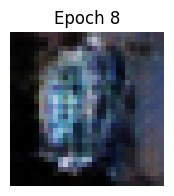

Epoch [8/10] Batch [0/782]                         Critic Loss: -2.4219 Generator Loss: -16.6572


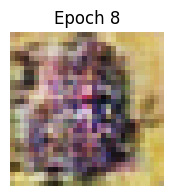

Epoch [8/10] Batch [0/782]                         Critic Loss: -2.4219 Generator Loss: -16.3965


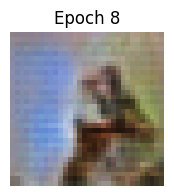

End of Epoch 8 | Critic Loss: -2.4219 | Generator Loss: -16.3965
End of Epoch 8 | Critic Loss: -2.8348 | Generator Loss: -17.1812
End of Epoch 8 | Critic Loss: -3.3698 | Generator Loss: -15.4508
End of Epoch 8 | Critic Loss: -3.3276 | Generator Loss: -15.4318
End of Epoch 8 | Critic Loss: -2.7760 | Generator Loss: -18.1462
End of Epoch 8 | Critic Loss: -2.1481 | Generator Loss: -16.7268
End of Epoch 8 | Critic Loss: -2.7353 | Generator Loss: -13.2969
End of Epoch 8 | Critic Loss: -4.3191 | Generator Loss: -15.4474
End of Epoch 8 | Critic Loss: -3.3837 | Generator Loss: -16.2291
End of Epoch 8 | Critic Loss: -3.6193 | Generator Loss: -13.3147
End of Epoch 8 | Critic Loss: -4.5128 | Generator Loss: -16.8556
End of Epoch 8 | Critic Loss: -2.3731 | Generator Loss: -13.9446
End of Epoch 8 | Critic Loss: -4.4586 | Generator Loss: -14.5866
End of Epoch 8 | Critic Loss: -2.6466 | Generator Loss: -16.0046
End of Epoch 8 | Critic Loss: -2.6916 | Generator Loss: -14.2776
End of Epoch 8 | Critic L

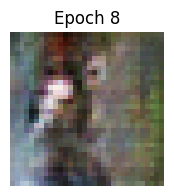

Epoch [8/10] Batch [200/782]                         Critic Loss: -3.6950 Generator Loss: -14.2403


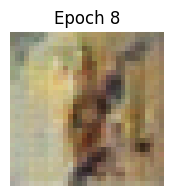

Epoch [8/10] Batch [200/782]                         Critic Loss: -3.6950 Generator Loss: -14.5045


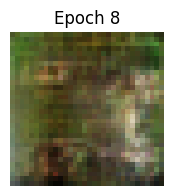

End of Epoch 8 | Critic Loss: -3.6950 | Generator Loss: -14.5045
End of Epoch 8 | Critic Loss: -3.5849 | Generator Loss: -13.4581
End of Epoch 8 | Critic Loss: -5.0314 | Generator Loss: -18.7257
End of Epoch 8 | Critic Loss: -2.2730 | Generator Loss: -17.5763
End of Epoch 8 | Critic Loss: -2.5534 | Generator Loss: -16.0390
End of Epoch 8 | Critic Loss: -3.3667 | Generator Loss: -15.2607
End of Epoch 8 | Critic Loss: -2.8207 | Generator Loss: -15.9168
End of Epoch 8 | Critic Loss: -4.1785 | Generator Loss: -14.0649
End of Epoch 8 | Critic Loss: -2.9504 | Generator Loss: -14.4882
End of Epoch 8 | Critic Loss: -2.9033 | Generator Loss: -14.9411
End of Epoch 8 | Critic Loss: -4.2497 | Generator Loss: -17.7686
End of Epoch 8 | Critic Loss: -3.0877 | Generator Loss: -13.6033
End of Epoch 8 | Critic Loss: -3.5722 | Generator Loss: -15.2954
End of Epoch 8 | Critic Loss: -3.6132 | Generator Loss: -14.4621
End of Epoch 8 | Critic Loss: -3.5757 | Generator Loss: -17.5002
End of Epoch 8 | Critic L

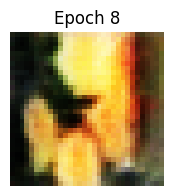

Epoch [8/10] Batch [400/782]                         Critic Loss: -3.3000 Generator Loss: -14.8556


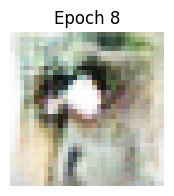

Epoch [8/10] Batch [400/782]                         Critic Loss: -3.3000 Generator Loss: -15.2179


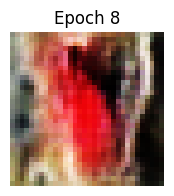

End of Epoch 8 | Critic Loss: -3.3000 | Generator Loss: -15.2179
End of Epoch 8 | Critic Loss: -3.8592 | Generator Loss: -13.0839
End of Epoch 8 | Critic Loss: -3.3988 | Generator Loss: -12.2008
End of Epoch 8 | Critic Loss: -3.7615 | Generator Loss: -17.0079
End of Epoch 8 | Critic Loss: -5.2674 | Generator Loss: -14.1891
End of Epoch 8 | Critic Loss: -2.7994 | Generator Loss: -17.4354
End of Epoch 8 | Critic Loss: -2.0515 | Generator Loss: -15.7769
End of Epoch 8 | Critic Loss: -3.3806 | Generator Loss: -15.6598
End of Epoch 8 | Critic Loss: -3.2150 | Generator Loss: -18.6030
End of Epoch 8 | Critic Loss: -4.0416 | Generator Loss: -16.4771
End of Epoch 8 | Critic Loss: -2.8787 | Generator Loss: -17.0252
End of Epoch 8 | Critic Loss: -3.2569 | Generator Loss: -12.3871
End of Epoch 8 | Critic Loss: -2.8246 | Generator Loss: -10.3620
End of Epoch 8 | Critic Loss: -3.8382 | Generator Loss: -14.4987
End of Epoch 8 | Critic Loss: -3.4795 | Generator Loss: -14.7971
End of Epoch 8 | Critic L

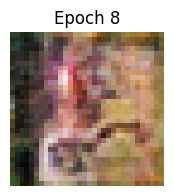

Epoch [8/10] Batch [600/782]                         Critic Loss: -2.3581 Generator Loss: -17.5413


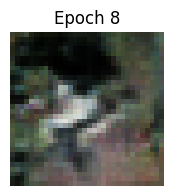

Epoch [8/10] Batch [600/782]                         Critic Loss: -2.3581 Generator Loss: -17.3680


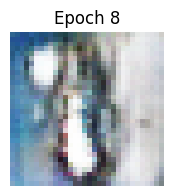

End of Epoch 8 | Critic Loss: -2.3581 | Generator Loss: -17.3680
End of Epoch 8 | Critic Loss: -3.4025 | Generator Loss: -12.4572
End of Epoch 8 | Critic Loss: -3.7869 | Generator Loss: -16.2029
End of Epoch 8 | Critic Loss: -2.5300 | Generator Loss: -18.2665
End of Epoch 8 | Critic Loss: -4.1401 | Generator Loss: -12.8227
End of Epoch 8 | Critic Loss: -4.1234 | Generator Loss: -14.5989
End of Epoch 8 | Critic Loss: -4.1276 | Generator Loss: -16.3972
End of Epoch 8 | Critic Loss: -2.5335 | Generator Loss: -15.8332
End of Epoch 8 | Critic Loss: -2.4941 | Generator Loss: -12.3147
End of Epoch 8 | Critic Loss: -4.1729 | Generator Loss: -17.7390
End of Epoch 8 | Critic Loss: -3.2774 | Generator Loss: -16.7355
End of Epoch 8 | Critic Loss: -4.3500 | Generator Loss: -16.8188
End of Epoch 8 | Critic Loss: -2.5091 | Generator Loss: -17.2940
End of Epoch 8 | Critic Loss: -2.7017 | Generator Loss: -13.9889
End of Epoch 8 | Critic Loss: -3.6254 | Generator Loss: -14.5837
End of Epoch 8 | Critic L

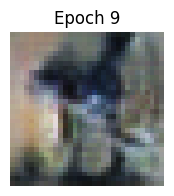

Epoch [9/10] Batch [0/782]                         Critic Loss: -2.9352 Generator Loss: -12.4572


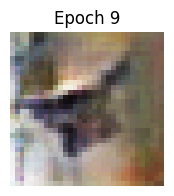

Epoch [9/10] Batch [0/782]                         Critic Loss: -2.9352 Generator Loss: -13.6130


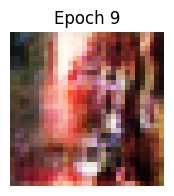

End of Epoch 9 | Critic Loss: -2.9352 | Generator Loss: -13.6130
End of Epoch 9 | Critic Loss: -3.6003 | Generator Loss: -13.9714
End of Epoch 9 | Critic Loss: -1.7817 | Generator Loss: -11.8325
End of Epoch 9 | Critic Loss: -3.4931 | Generator Loss: -14.2578
End of Epoch 9 | Critic Loss: -2.9695 | Generator Loss: -15.8487
End of Epoch 9 | Critic Loss: -3.0690 | Generator Loss: -20.4727
End of Epoch 9 | Critic Loss: -2.3966 | Generator Loss: -18.6440
End of Epoch 9 | Critic Loss: -3.2927 | Generator Loss: -19.3388
End of Epoch 9 | Critic Loss: -2.9417 | Generator Loss: -14.2711
End of Epoch 9 | Critic Loss: -3.5752 | Generator Loss: -11.2458
End of Epoch 9 | Critic Loss: -3.6776 | Generator Loss: -16.8392
End of Epoch 9 | Critic Loss: -3.9940 | Generator Loss: -19.9150
End of Epoch 9 | Critic Loss: -3.7033 | Generator Loss: -22.9464
End of Epoch 9 | Critic Loss: -4.1992 | Generator Loss: -18.1195
End of Epoch 9 | Critic Loss: -2.6953 | Generator Loss: -18.1640
End of Epoch 9 | Critic L

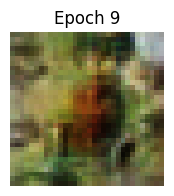

Epoch [9/10] Batch [200/782]                         Critic Loss: -2.8405 Generator Loss: -17.8294


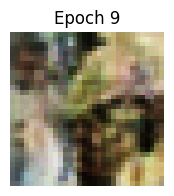

Epoch [9/10] Batch [200/782]                         Critic Loss: -2.8405 Generator Loss: -18.4324


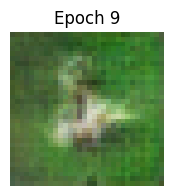

End of Epoch 9 | Critic Loss: -2.8405 | Generator Loss: -18.4324
End of Epoch 9 | Critic Loss: -3.3621 | Generator Loss: -15.9305
End of Epoch 9 | Critic Loss: -3.5371 | Generator Loss: -19.9767
End of Epoch 9 | Critic Loss: -2.9611 | Generator Loss: -18.1207
End of Epoch 9 | Critic Loss: -3.4422 | Generator Loss: -18.5415
End of Epoch 9 | Critic Loss: -3.5647 | Generator Loss: -19.0532
End of Epoch 9 | Critic Loss: -3.2327 | Generator Loss: -19.4387
End of Epoch 9 | Critic Loss: -3.1372 | Generator Loss: -20.4100
End of Epoch 9 | Critic Loss: -2.9263 | Generator Loss: -19.8922
End of Epoch 9 | Critic Loss: -3.1805 | Generator Loss: -18.1277
End of Epoch 9 | Critic Loss: -3.7597 | Generator Loss: -14.3945
End of Epoch 9 | Critic Loss: -3.6457 | Generator Loss: -13.8936
End of Epoch 9 | Critic Loss: -3.7353 | Generator Loss: -20.4935
End of Epoch 9 | Critic Loss: -4.3989 | Generator Loss: -22.4661
End of Epoch 9 | Critic Loss: -2.5564 | Generator Loss: -19.6229
End of Epoch 9 | Critic L

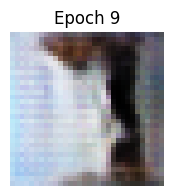

Epoch [9/10] Batch [400/782]                         Critic Loss: -1.5024 Generator Loss: -12.9023


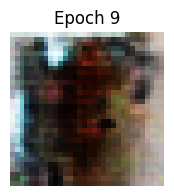

Epoch [9/10] Batch [400/782]                         Critic Loss: -1.5024 Generator Loss: -13.2049


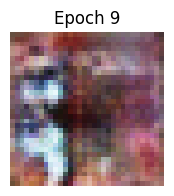

End of Epoch 9 | Critic Loss: -1.5024 | Generator Loss: -13.2049
End of Epoch 9 | Critic Loss: -2.4149 | Generator Loss: -16.6226
End of Epoch 9 | Critic Loss: -4.3416 | Generator Loss: -19.8729
End of Epoch 9 | Critic Loss: -3.1564 | Generator Loss: -18.1478
End of Epoch 9 | Critic Loss: -2.8519 | Generator Loss: -19.3489
End of Epoch 9 | Critic Loss: -1.7924 | Generator Loss: -15.3846
End of Epoch 9 | Critic Loss: -2.6054 | Generator Loss: -17.8402
End of Epoch 9 | Critic Loss: -2.3710 | Generator Loss: -19.8221
End of Epoch 9 | Critic Loss: -2.8710 | Generator Loss: -17.3573
End of Epoch 9 | Critic Loss: -2.9689 | Generator Loss: -16.8575
End of Epoch 9 | Critic Loss: -2.9835 | Generator Loss: -17.3924
End of Epoch 9 | Critic Loss: -3.9267 | Generator Loss: -13.8550
End of Epoch 9 | Critic Loss: -3.8430 | Generator Loss: -15.5066
End of Epoch 9 | Critic Loss: -3.5636 | Generator Loss: -16.3372
End of Epoch 9 | Critic Loss: -2.6276 | Generator Loss: -20.1961
End of Epoch 9 | Critic L

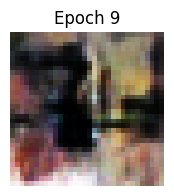

Epoch [9/10] Batch [600/782]                         Critic Loss: -2.1679 Generator Loss: -18.7694


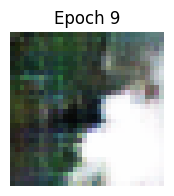

Epoch [9/10] Batch [600/782]                         Critic Loss: -2.1679 Generator Loss: -19.4280


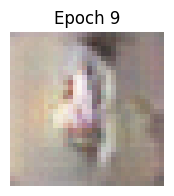

End of Epoch 9 | Critic Loss: -2.1679 | Generator Loss: -19.4280
End of Epoch 9 | Critic Loss: -3.0762 | Generator Loss: -19.2989
End of Epoch 9 | Critic Loss: -3.8222 | Generator Loss: -15.8052
End of Epoch 9 | Critic Loss: -3.0571 | Generator Loss: -19.5149
End of Epoch 9 | Critic Loss: -3.2098 | Generator Loss: -19.7507
End of Epoch 9 | Critic Loss: -2.6217 | Generator Loss: -21.6102
End of Epoch 9 | Critic Loss: -2.5931 | Generator Loss: -20.9375
End of Epoch 9 | Critic Loss: -3.2869 | Generator Loss: -20.2845
End of Epoch 9 | Critic Loss: -2.9349 | Generator Loss: -16.5654
End of Epoch 9 | Critic Loss: -3.0315 | Generator Loss: -17.6453
End of Epoch 9 | Critic Loss: -2.5768 | Generator Loss: -19.0843
End of Epoch 9 | Critic Loss: -3.7046 | Generator Loss: -15.2126
End of Epoch 9 | Critic Loss: -3.2150 | Generator Loss: -18.5002
End of Epoch 9 | Critic Loss: -4.4087 | Generator Loss: -21.8163
End of Epoch 9 | Critic Loss: -2.0137 | Generator Loss: -19.9656
End of Epoch 9 | Critic L

In [33]:
lambda_gp = 10
critic_iterations = 5
epochs = 10

for epoch in range(epochs):
    for batch_idx, (real, _) in enumerate(loader):

        real = real.to(device)
        batch_size = real.size(0)

        # ---------------------
        # Train Critic
        # ---------------------
        for _ in range(critic_iterations):

            noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
            fake = net_G(noise)

            D_real = net_D(real)
            D_fake = net_D(fake.detach())

            gp = gradient_penalty(net_D, real, fake, device)

            loss_D = -(torch.mean(D_real) - torch.mean(D_fake)) + lambda_gp * gp

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        for _ in range (3):
            noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
            fake = net_G(noise)
            D_fake = net_D(fake)

            loss_G = -torch.mean(D_fake)

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            if batch_idx % 200 == 0: # Print every 10 batches
                print(f"Epoch [{epoch}/{epochs}] Batch [{batch_idx}/{len(loader)}] \
                        Critic Loss: {loss_D:.4f} Generator Loss: {loss_G:.4f}")
                img = fake[0].permute(2,1,0).detach().cpu().squeeze().numpy()
                img = (img + 1) / 2

                plt.figure(figsize=(2,2))
                plt.imshow(img, cmap='gray')
                plt.title(f"Epoch {epoch}")
                plt.axis('off')
                plt.show()

    # Optionally, print end-of-epoch summary
        print(f"End of Epoch {epoch} | Critic Loss: {loss_D:.4f} | Generator Loss: {loss_G:.4f}")